# 📡 No-Churn Telecom — Customer Churn Prediction
**Project Ref:** PM-PR-0017  
**Client:** No-Churn Telecom  
**Category:** Telecom – Churn Rate Machine Learning  

---

## Project Goals
1. Identify the key variables influencing customer churn  
2. Predict customers likely to churn  
3. Generate a new variable `CHURN_FLAG` (YES=1 / NO=0)  
4. Enable marketing & support teams to target high-risk customers  

---
### Notebook Structure
| # | Section |
|---|---|
| 1 | Imports & Setup |
| 2 | Data Loading (CSV + SQL simulation) |
| 3 | Exploratory Data Analysis (EDA) |
| 4 | Feature Engineering |
| 5 | Pre-processing & Pipeline |
| 6 | Model Building & Evaluation |
| 7 | Best Model Selection |
| 8 | CHURN_FLAG Generation |
| 9 | Business Insights & Recommendations |

## 1. Imports & Setup

In [1]:
# ── Core ──────────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

# ── Visualisation ──────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

# ── ML ────────────────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score
)

from scipy import stats

print('✅ All libraries loaded successfully.')

✅ All libraries loaded successfully.


## 2. Data Loading

### 2a. SQL Query Simulation
The project spec references a live MySQL database. Below is the SQL query that would be used in production to pull the data. We then load it from the provided CSV for this notebook.

In [2]:
# ── SQL Connection Details (Production) ───────────────────────────────────────
# Host     : 18.136.157.135
# Schema   : project_telecom
# Table    : telecom_churn_data
# Username : dm_team3

SQL_QUERY = """
-- ============================================================
--  No-Churn Telecom  |  Churn Data Extraction
--  Schema  : project_telecom
--  Table   : telecom_churn_data
-- ============================================================

SELECT
    customer_id,
    telecom_partner,
    gender,
    age,
    state,
    city,
    pincode,
    date_of_registration,
    num_dependents,
    estimated_salary,
    calls_made,
    sms_sent,
    data_used,
    churn
FROM
    project_telecom.telecom_churn_data
WHERE
    date_of_registration IS NOT NULL
    AND customer_id IS NOT NULL
ORDER BY
    customer_id;
"""

print('📋 SQL Query ready.')
print(SQL_QUERY)

# ── Production connection code (commented out — requires MySQL driver) ─────────
import mysql.connector
import pandas as pd

conn = mysql.connector.connect(
    host='18.136.157.135',
    database='project_telecom',
    user='dm_team3',
    password='DM!$!Team!27@9!20&'
)

query = """
SELECT *
FROM project_telecom.telecom_churn_data
"""

df = pd.read_sql(query, conn)
conn.close()

print(df.shape)
df.head()

📋 SQL Query ready.

-- ============================================================
--  No-Churn Telecom  |  Churn Data Extraction
--  Schema  : project_telecom
--  Table   : telecom_churn_data
-- ============================================================

SELECT
    customer_id,
    telecom_partner,
    gender,
    age,
    state,
    city,
    pincode,
    date_of_registration,
    num_dependents,
    estimated_salary,
    calls_made,
    sms_sent,
    data_used,
    churn
FROM
    project_telecom.telecom_churn_data
WHERE
    date_of_registration IS NOT NULL
    AND customer_id IS NOT NULL
ORDER BY
    customer_id;

(243553, 14)


,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
0,1,Reliance Jio,F,25,Karnataka,Kolkata,755597,2020-01-01,4,124962,44,45,-361,0
1,2,Reliance Jio,F,55,Mizoram,Mumbai,125926,2020-01-01,2,130556,62,39,5973,0
2,3,Vodafone,F,57,Arunachal Pradesh,Delhi,423976,2020-01-01,0,148828,49,24,193,1
3,4,BSNL,M,46,Tamil Nadu,Kolkata,522841,2020-01-01,1,38722,80,25,9377,1
4,5,BSNL,F,26,Tripura,Delhi,740247,2020-01-01,2,55098,78,15,1393,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 243553 entries, 0 to 243552
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   customer_id           243553 non-null  int64
 1   telecom_partner       243553 non-null  str  
 2   gender                243553 non-null  str  
 3   age                   243553 non-null  int64
 4   state                 243553 non-null  str  
 5   city                  243553 non-null  str  
 6   pincode               243553 non-null  int64
 7   date_of_registration  243553 non-null  str  
 8   num_dependents        243553 non-null  int64
 9   estimated_salary      243553 non-null  int64
 10  calls_made            243553 non-null  int64
 11  sms_sent              243553 non-null  int64
 12  data_used             243553 non-null  int64
 13  churn                 243553 non-null  int64
dtypes: int64(9), str(5)
memory usage: 26.0 MB


In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,243553.0,NaN,NaN,NaN,121777.0,70307.839393,1.0,60889.0,121777.0,182665.0,243553.0
telecom_partner,243553,4,Reliance Jio,61123,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,243553,2,M,145977,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,243553.0,NaN,NaN,NaN,46.077609,16.444029,18.0,32.0,46.0,60.0,74.0
state,243553,28,Uttarakhand,8856,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,243553,6,Chennai,40749,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pincode,243553.0,NaN,NaN,NaN,549501.270541,259808.860574,100006.0,324586.0,548112.0,774994.0,999987.0
date_of_registration,243553,1220,2020-01-01,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
num_dependents,243553.0,NaN,NaN,NaN,1.9975,1.414941,0.0,1.0,2.0,3.0,4.0
estimated_salary,243553.0,NaN,NaN,NaN,85021.137839,37508.963233,20000.0,52585.0,84990.0,117488.0,149999.0


## 3. Exploratory Data Analysis (EDA)

In [5]:
# ── Missing values ─────────────────────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

if missing_df.empty:
    print('✅ No missing values found.')
else:
    print(missing_df)

✅ No missing values found.


In [6]:
# ── Duplicates ────────────────────────────────────────────────────────────────
dups = df.duplicated().sum()
print(f'Duplicate rows: {dups}')

# ── Negative / anomalous values ───────────────────────────────────────────────
print(f"\nNegative data_used values : {(df['data_used'] < 0).sum()}")
print(f"Negative calls_made       : {(df['calls_made'] < 0).sum()}")
print(f"Negative sms_sent         : {(df['sms_sent'] < 0).sum()}")

Duplicate rows: 0

Negative data_used values : 6050
Negative calls_made       : 6713
Negative sms_sent         : 7375


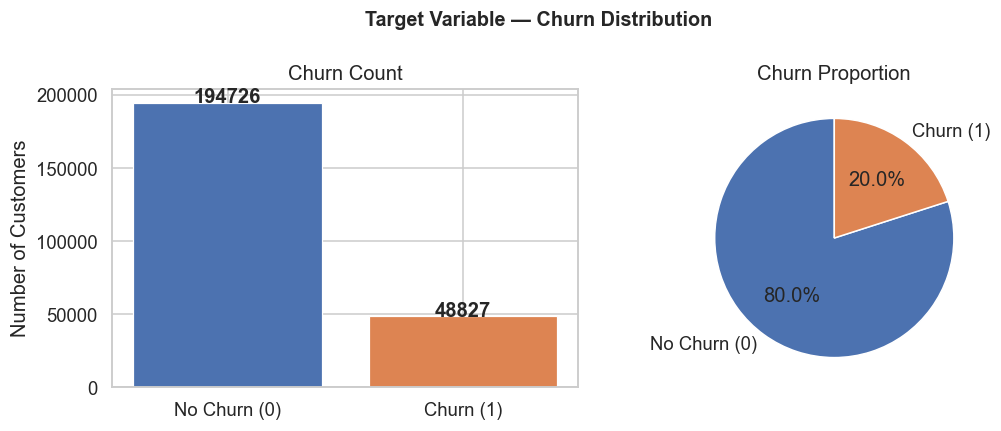

Churn Rate: 20.0%


In [7]:
# ── Target variable distribution ──────────────────────────────────────────────
churn_counts = df['churn'].value_counts()
churn_pct    = df['churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar
axes[0].bar(['No Churn (0)', 'Churn (1)'], churn_counts.values,
            color=['#4C72B0', '#DD8452'], edgecolor='white', linewidth=0.8)
axes[0].set_title('Churn Count')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie
axes[1].pie(churn_counts.values, labels=['No Churn (0)', 'Churn (1)'],
            autopct='%1.1f%%', colors=['#4C72B0', '#DD8452'],
            startangle=90, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Churn Proportion')

plt.suptitle('Target Variable — Churn Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Churn Rate: {churn_pct[1]:.1f}%')

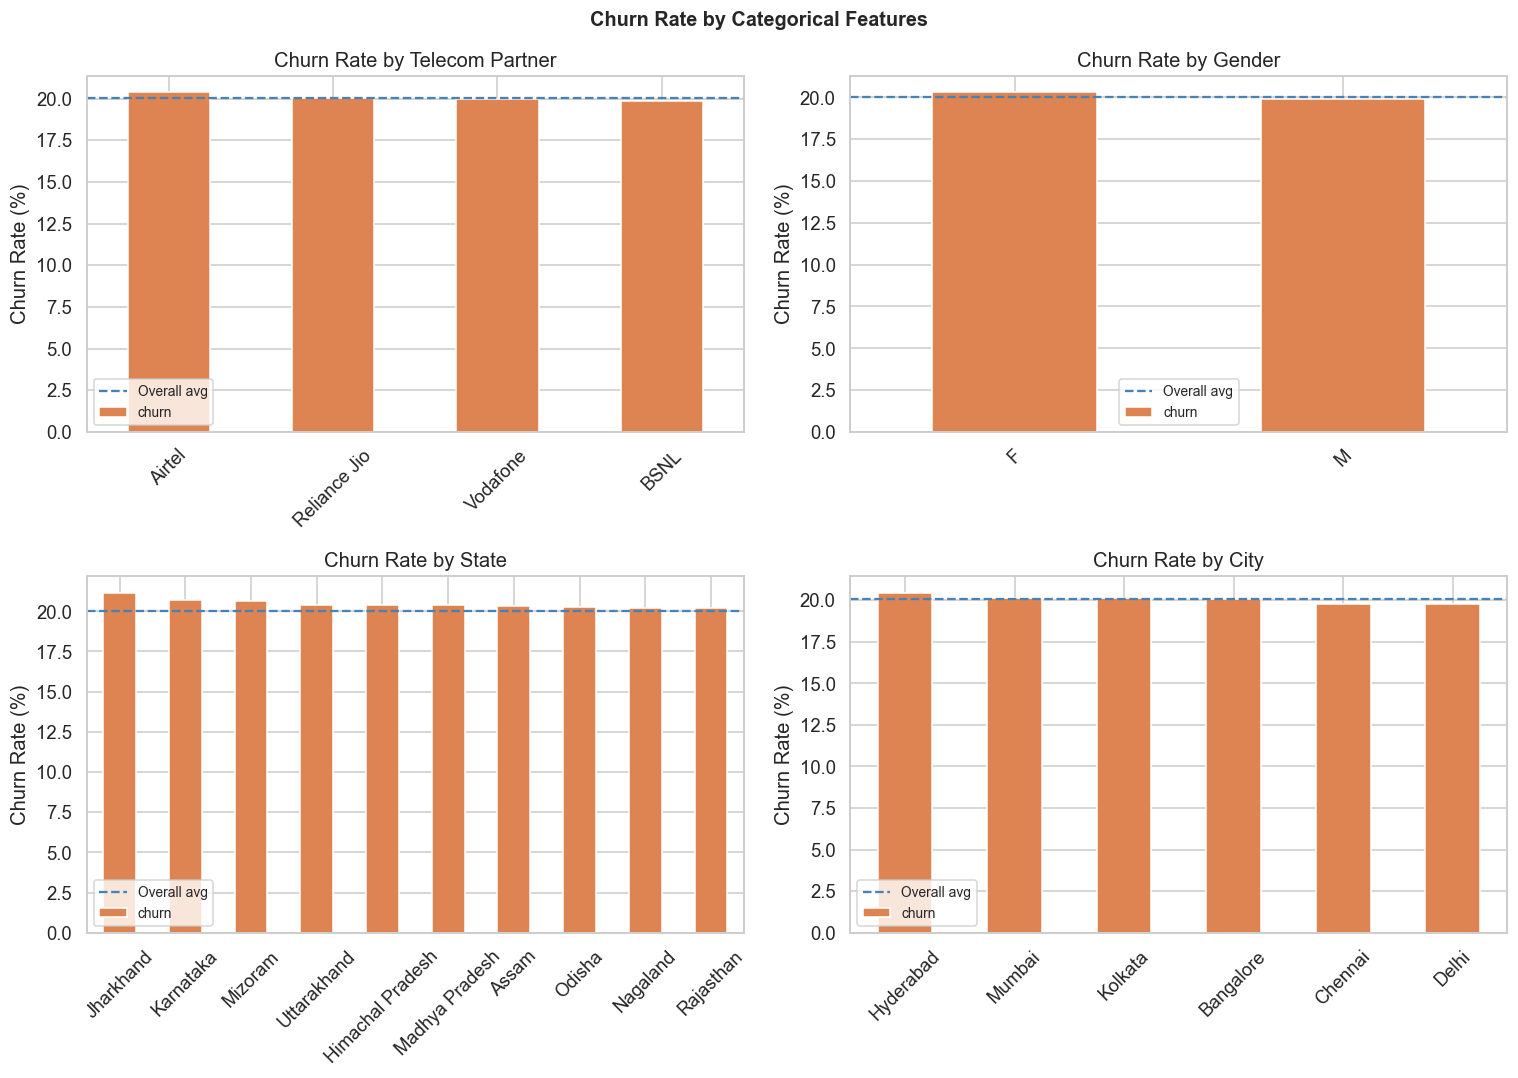

In [8]:
# ── Categorical feature analysis ──────────────────────────────────────────────
cat_cols = ['telecom_partner', 'gender', 'state', 'city']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_by = df.groupby(col)['churn'].mean().sort_values(ascending=False) * 100
    if len(churn_by) > 10:
        churn_by = churn_by.head(10)
    churn_by.plot(kind='bar', ax=axes[i], color='#DD8452', edgecolor='white')
    axes[i].set_title(f'Churn Rate by {col.replace("_", " ").title()}')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].axhline(df['churn'].mean() * 100, color='steelblue',
                    linestyle='--', linewidth=1.5, label='Overall avg')
    axes[i].legend(fontsize=9)

plt.suptitle('Churn Rate by Categorical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

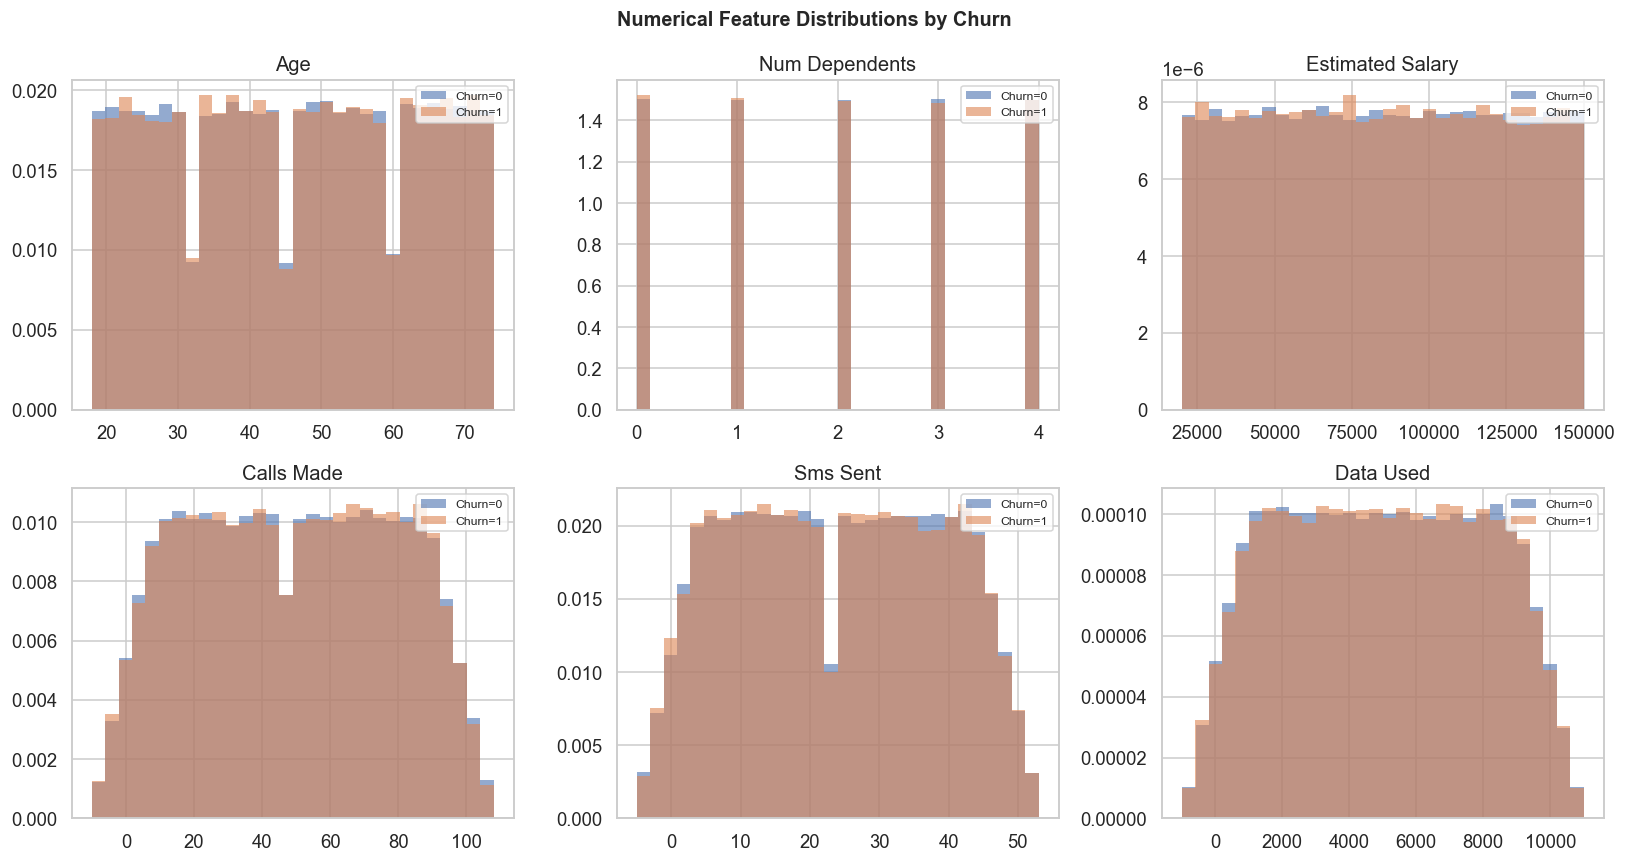

In [9]:
# ── Numerical feature distributions by churn ──────────────────────────────────
num_cols = ['age', 'num_dependents', 'estimated_salary', 'calls_made', 'sms_sent', 'data_used']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for label, color in zip([0, 1], ['#4C72B0', '#DD8452']):
        subset = df[df['churn'] == label][col]
        axes[i].hist(subset, bins=30, alpha=0.6, color=color,
                     label=f'Churn={label}', density=True, edgecolor='none')
    axes[i].set_title(col.replace('_', ' ').title())
    axes[i].legend(fontsize=8)

plt.suptitle('Numerical Feature Distributions by Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

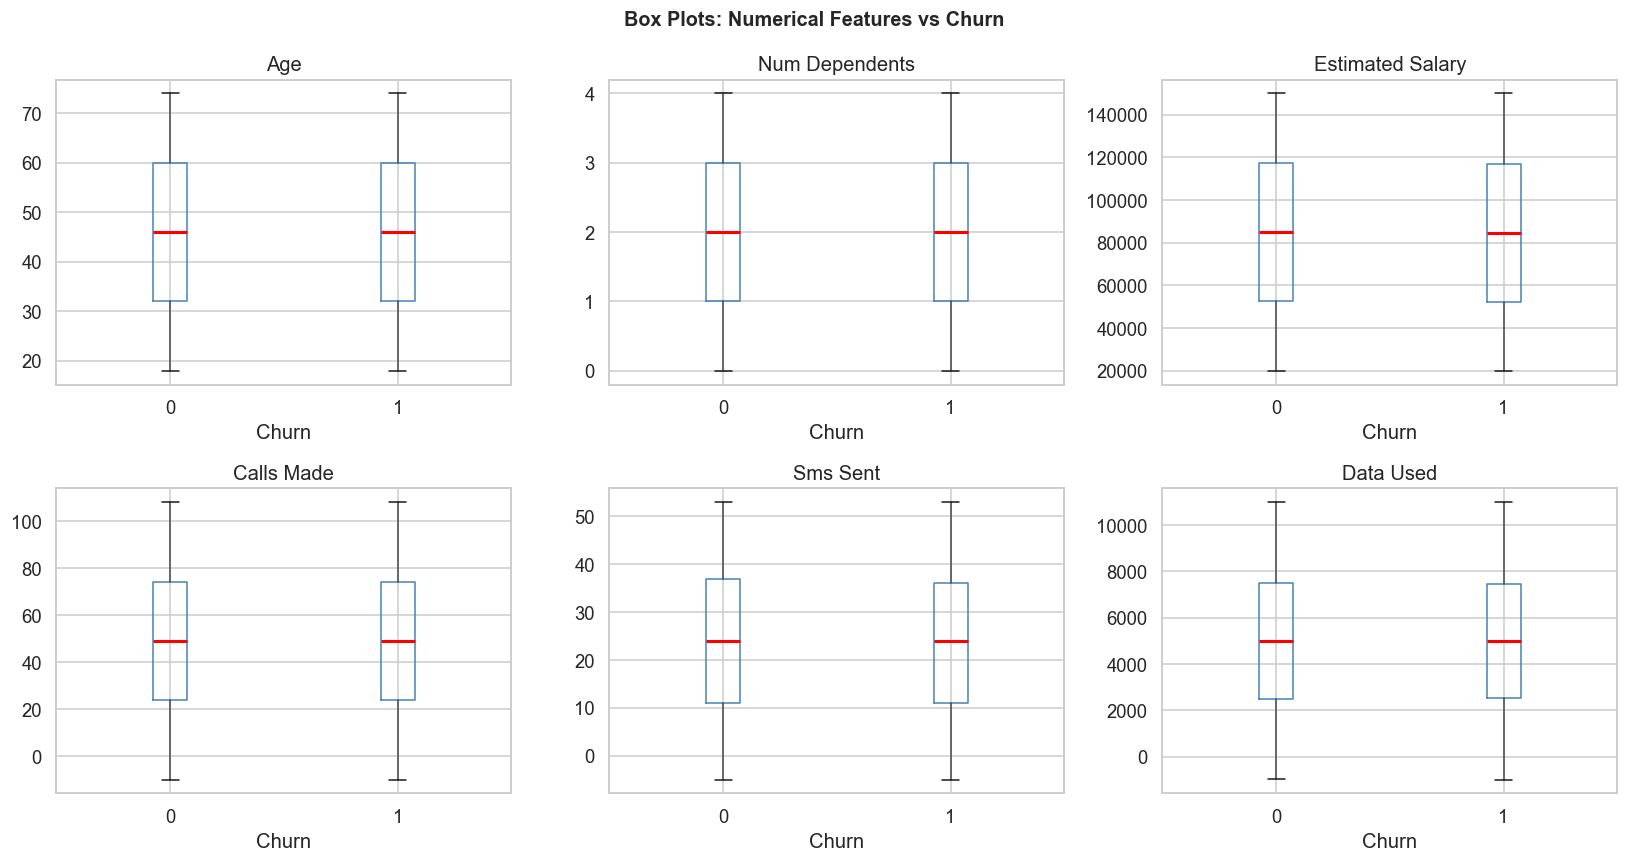

In [10]:
# ── Box plots ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    df.boxplot(column=col, by='churn', ax=axes[i],
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col.replace('_', ' ').title())
    axes[i].set_xlabel('Churn')

plt.suptitle('Box Plots: Numerical Features vs Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

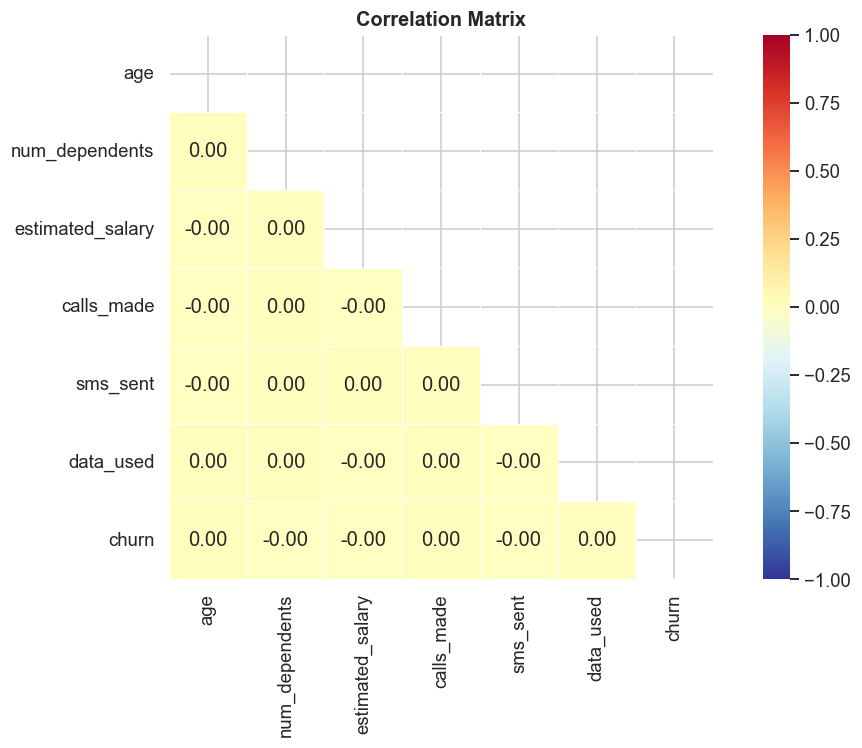

In [11]:
# ── Correlation heatmap ───────────────────────────────────────────────────────
corr_df = df[num_cols + ['churn']].copy()
# Treat negative data_used as 0 for correlation purposes
corr_df['data_used'] = corr_df['data_used'].clip(lower=0)

plt.figure(figsize=(10, 7))
corr_matrix = corr_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlBu_r', vmin=-1, vmax=1,
            square=True, linewidths=0.5)
plt.title('Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
# ── Statistical significance tests ────────────────────────────────────────────
print('=== Mann-Whitney U Test: Numerical Features vs Churn ===')
print(f'{"Feature":<22} {"U-stat":>12} {"p-value":>12} {"Significant?":>14}')
print('-' * 62)

churn_yes = df[df['churn'] == 1]
churn_no  = df[df['churn'] == 0]

for col in num_cols:
    u_stat, p_val = stats.mannwhitneyu(
        churn_yes[col].dropna(),
        churn_no[col].dropna(),
        alternative='two-sided'
    )
    sig = '✅ Yes' if p_val < 0.05 else '❌ No'
    print(f'{col:<22} {u_stat:>12.0f} {p_val:>12.4f} {sig:>14}')

print('\n=== Chi-Square Test: Categorical Features vs Churn ===')
print(f'{"Feature":<20} {"Chi2":>10} {"p-value":>12} {"Significant?":>14}')
print('-' * 58)

for col in ['telecom_partner', 'gender', 'state']:
    ct = pd.crosstab(df[col], df['churn'])
    chi2, p_val, dof, _ = stats.chi2_contingency(ct)
    sig = '✅ Yes' if p_val < 0.05 else '❌ No'
    print(f'{col:<20} {chi2:>10.2f} {p_val:>12.4f} {sig:>14}')

=== Mann-Whitney U Test: Numerical Features vs Churn ===
Feature                      U-stat      p-value   Significant?
--------------------------------------------------------------
age                      4759695726       0.6788           ❌ No
num_dependents           4736856158       0.2093           ❌ No
estimated_salary         4731114818       0.1003           ❌ No
calls_made               4766926536       0.3500           ❌ No
sms_sent                 4732850656       0.1289           ❌ No
data_used                4759458687       0.6913           ❌ No

=== Chi-Square Test: Categorical Features vs Churn ===
Feature                    Chi2      p-value   Significant?
----------------------------------------------------------
telecom_partner            5.59       0.1332           ❌ No
gender                     6.28       0.0122          ✅ Yes
state                     25.22       0.5624           ❌ No


## 4. Feature Engineering

In [18]:
df_fe = df.copy()

# ── Date features ─────────────────────────────────────────────────────────────
df_fe['date_of_registration'] = pd.to_datetime(df_fe['date_of_registration'], errors='coerce')
reference_date = pd.Timestamp('2024-01-01')
df_fe['tenure_days']   = (reference_date - df_fe['date_of_registration']).dt.days
df_fe['reg_year']      = df_fe['date_of_registration'].dt.year
df_fe['reg_month']     = df_fe['date_of_registration'].dt.month
df_fe['reg_quarter']   = df_fe['date_of_registration'].dt.quarter

# ── Fix negative data_used ────────────────────────────────────────────────────
df_fe['data_used'] = df_fe['data_used'].clip(lower=0)

# ── Usage aggregates ──────────────────────────────────────────────────────────
df_fe['total_activity']    = df_fe['calls_made'] + df_fe['sms_sent'] + df_fe['data_used']
df_fe['call_sms_ratio'] = (df_fe['calls_made'] / (df_fe['sms_sent'] + 1)).replace([np.inf, -np.inf], 0).fillna(0)
df_fe['data_per_call']  = (df_fe['data_used']  / (df_fe['calls_made'] + 1)).replace([np.inf, -np.inf], 0).fillna(0)
df_fe['salary_per_dep'] = (df_fe['estimated_salary'] / (df_fe['num_dependents'] + 1)).replace([np.inf, -np.inf], 0).fillna(0)

# ── Age groups ────────────────────────────────────────────────────────────────
df_fe['age_group'] = pd.cut(
    df_fe['age'],
    bins=[0, 25, 35, 45, 55, 100],
    labels=['<25', '25-35', '35-45', '45-55', '55+']
)

# ── Salary bins ───────────────────────────────────────────────────────────────
df_fe['salary_band'] = pd.qcut(
    df_fe['estimated_salary'], q=4,
    labels=['Low', 'Mid-Low', 'Mid-High', 'High']
)

# ── High data user flag ───────────────────────────────────────────────────────
df_fe['is_high_data_user'] = (df_fe['data_used'] > df_fe['data_used'].median()).astype(int)

print('✅ Feature engineering complete.')
print(f'New columns added: {df_fe.shape[1] - df.shape[1]}')
print('\nNew features:')
new_feats = [c for c in df_fe.columns if c not in df.columns]
for f in new_feats:
    print(f'  • {f}')

✅ Feature engineering complete.
New columns added: 11

New features:
  • tenure_days
  • reg_year
  • reg_month
  • reg_quarter
  • total_activity
  • call_sms_ratio
  • data_per_call
  • salary_per_dep
  • age_group
  • salary_band
  • is_high_data_user


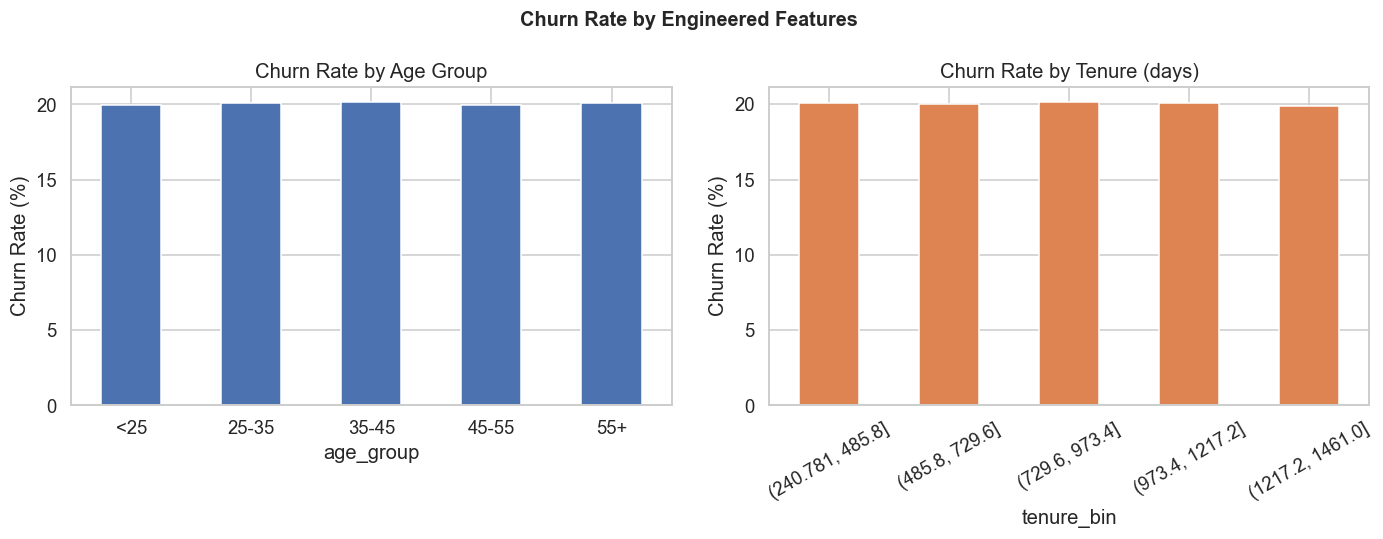

In [19]:
# ── Churn rate by engineered features ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Age group
cr_age = df_fe.groupby('age_group', observed=True)['churn'].mean() * 100
cr_age.plot(kind='bar', ax=axes[0], color='#4C72B0', edgecolor='white')
axes[0].set_title('Churn Rate by Age Group')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].tick_params(axis='x', rotation=0)

# Tenure
df_fe['tenure_bin'] = pd.cut(df_fe['tenure_days'], bins=5)
cr_ten = df_fe.groupby('tenure_bin', observed=True)['churn'].mean() * 100
cr_ten.plot(kind='bar', ax=axes[1], color='#DD8452', edgecolor='white')
axes[1].set_title('Churn Rate by Tenure (days)')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Churn Rate by Engineered Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Pre-processing & Pipeline Setup

In [20]:
# ── Select modelling columns ───────────────────────────────────────────────────
FEATURES = [
    'age', 'num_dependents', 'estimated_salary',
    'calls_made', 'sms_sent', 'data_used',
    'tenure_days', 'total_activity', 'call_sms_ratio',
    'data_per_call', 'salary_per_dep', 'is_high_data_user',
    'telecom_partner', 'gender', 'age_group', 'salary_band'
]

TARGET = 'churn'

X = df_fe[FEATURES].copy()
y = df_fe[TARGET].copy()

# ── Column types ──────────────────────────────────────────────────────────────
num_features = X.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f'Numerical features  ({len(num_features)}): {num_features}')
print(f'Categorical features ({len(cat_features)}): {cat_features}')

# ── Train / Test split ────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'\nTrain size : {X_train.shape[0]}  |  Test size: {X_test.shape[0]}')
print(f'Train churn: {y_train.mean()*100:.1f}%  |  Test churn: {y_test.mean()*100:.1f}%')

Numerical features  (12): ['age', 'num_dependents', 'estimated_salary', 'calls_made', 'sms_sent', 'data_used', 'tenure_days', 'total_activity', 'call_sms_ratio', 'data_per_call', 'salary_per_dep', 'is_high_data_user']
Categorical features (4): ['telecom_partner', 'gender', 'age_group', 'salary_band']

Train size : 194842  |  Test size: 48711
Train churn: 20.0%  |  Test churn: 20.0%


In [21]:
# ── Pre-processing pipeline ───────────────────────────────────────────────────
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

print('✅ Pre-processing pipeline defined.')

✅ Pre-processing pipeline defined.


## 6. Model Building & Evaluation

In [23]:
# ── Define models ─────────────────────────────────────────────────────────────
from sklearn.utils import class_weight

# ── Tell models to pay more attention to the minority class (churners) ─────────
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42,
                                                class_weight='balanced'),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=6, random_state=42,
                                                    class_weight='balanced'),
    'Random Forest'       : RandomForestClassifier(n_estimators=150, random_state=42,
                                                    n_jobs=-1, class_weight='balanced'),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=150, random_state=42),
    'K-Nearest Neighbors' : KNeighborsClassifier(n_neighbors=7),
    'Naive Bayes'         : GaussianNB(),
    'SVM'                 : SVC(probability=True, kernel='rbf', random_state=42,
                                class_weight='balanced'),
}

cv   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print(f'{"Model":<26} {"CV AUC":>8} {"CV Acc":>8} {"Test AUC":>10} {"Test Acc":>10}')
print('-' * 65)

for name, clf in models.items():
    pipe = Pipeline([('prep', preprocessor), ('clf', clf)])

    cv_auc = cross_val_score(pipe, X_train, y_train, cv=cv,
                              scoring='roc_auc', n_jobs=-1).mean()
    cv_acc = cross_val_score(pipe, X_train, y_train, cv=cv,
                              scoring='accuracy', n_jobs=-1).mean()

    pipe.fit(X_train, y_train)
    y_pred      = pipe.predict(X_test)
    y_prob      = pipe.predict_proba(X_test)[:, 1]
    test_auc    = roc_auc_score(y_test, y_prob)
    test_acc    = accuracy_score(y_test, y_pred)

    results[name] = {
        'pipeline'  : pipe,
        'cv_auc'    : cv_auc,
        'cv_acc'    : cv_acc,
        'test_auc'  : test_auc,
        'test_acc'  : test_acc,
        'y_pred'    : y_pred,
        'y_prob'    : y_prob,
    }

    print(f'{name:<26} {cv_auc:>8.4f} {cv_acc:>8.4f} {test_auc:>10.4f} {test_acc:>10.4f}')

print('\n✅ All models trained.')

Model                        CV AUC   CV Acc   Test AUC   Test Acc
-----------------------------------------------------------------


KeyboardInterrupt: 

In [ ]:
# ── Model comparison bar chart ────────────────────────────────────────────────
res_df = pd.DataFrame({
    'Model'    : list(results.keys()),
    'CV AUC'   : [v['cv_auc']   for v in results.values()],
    'Test AUC' : [v['test_auc'] for v in results.values()],
    'Test Acc' : [v['test_acc'] for v in results.values()],
}).sort_values('Test AUC', ascending=False)

x = np.arange(len(res_df))
w = 0.28

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - w,   res_df['CV AUC'],   w, label='CV AUC',   color='#4C72B0', alpha=0.85)
ax.bar(x,       res_df['Test AUC'], w, label='Test AUC', color='#DD8452', alpha=0.85)
ax.bar(x + w,   res_df['Test Acc'], w, label='Test Acc', color='#55A868', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(res_df['Model'], rotation=25, ha='right')
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('Score')
ax.set_title('Model Comparison: AUC & Accuracy', fontsize=13, fontweight='bold')
ax.legend()
ax.axhline(0.8, color='red', linestyle='--', linewidth=0.8, alpha=0.7, label='0.8 threshold')
plt.tight_layout()
plt.show()

In [ ]:
# ── ROC Curves ────────────────────────────────────────────────────────────────
plt.figure(figsize=(9, 7))
colors = plt.cm.tab10(np.linspace(0, 1, len(results)))

for (name, v), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, v['y_prob'])
    plt.plot(fpr, tpr, label=f"{name}  (AUC={v['test_auc']:.3f})", color=color, linewidth=1.8)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.6)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models', fontsize=13, fontweight='bold')
plt.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()

In [ ]:
# ── Confusion matrices for top 4 models ───────────────────────────────────────
top4 = res_df.head(4)['Model'].tolist()

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, name in zip(axes, top4):
    cm = confusion_matrix(y_test, results[name]['y_pred'])
    ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn']).plot(
        ax=ax, colorbar=False, cmap='Blues'
    )
    ax.set_title(name, fontsize=9)

plt.suptitle('Confusion Matrices — Top 4 Models', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Best Model — Detailed Analysis

In [ ]:
# ── Select best model by Test AUC ─────────────────────────────────────────────
best_name = res_df.iloc[0]['Model']
best      = results[best_name]

print(f'🏆 Best Model : {best_name}')
print(f'   CV AUC    : {best["cv_auc"]:.4f}')
print(f'   Test AUC  : {best["test_auc"]:.4f}')
print(f'   Test Acc  : {best["test_acc"]:.4f}')

print('\n── Classification Report ───────────────────────────────────────')
print(classification_report(y_test, best['y_pred'], target_names=['No Churn', 'Churn']))

In [ ]:
# ── Feature importance (tree-based models) ────────────────────────────────────
clf_step = best['pipeline'].named_steps['clf']
prep_step = best['pipeline'].named_steps['prep']

if hasattr(clf_step, 'feature_importances_'):
    # Get feature names after OHE
    ohe_cols = prep_step.named_transformers_['cat']['ohe']\
                        .get_feature_names_out(cat_features).tolist()
    all_feature_names = num_features + ohe_cols

    fi = pd.Series(clf_step.feature_importances_, index=all_feature_names)
    fi_top = fi.sort_values(ascending=False).head(15)

    plt.figure(figsize=(9, 6))
    fi_top.sort_values().plot(kind='barh', color='#4C72B0', edgecolor='white')
    plt.title(f'Top 15 Feature Importances — {best_name}',
              fontsize=12, fontweight='bold')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
else:
    # Logistic Regression coefficients
    if hasattr(clf_step, 'coef_'):
        ohe_cols = prep_step.named_transformers_['cat']['ohe']\
                            .get_feature_names_out(cat_features).tolist()
        all_feature_names = num_features + ohe_cols
        coefs = pd.Series(np.abs(clf_step.coef_[0]), index=all_feature_names)
        coefs_top = coefs.sort_values(ascending=False).head(15)

        plt.figure(figsize=(9, 6))
        coefs_top.sort_values().plot(kind='barh', color='#DD8452', edgecolor='white')
        plt.title(f'Top 15 |Coefficients| — {best_name}',
                  fontsize=12, fontweight='bold')
        plt.xlabel('|Coefficient|')
        plt.tight_layout()
        plt.show()
    else:
        print(f'Feature importance not directly available for {best_name}.')

In [ ]:
# ── Precision-Recall curve ────────────────────────────────────────────────────
prec, rec, thresh = precision_recall_curve(y_test, best['y_prob'])
ap = average_precision_score(y_test, best['y_prob'])

plt.figure(figsize=(8, 5))
plt.plot(rec, prec, color='#DD8452', linewidth=2)
plt.fill_between(rec, prec, alpha=0.2, color='#DD8452')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve — {best_name}  (AP={ap:.3f})',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. CHURN_FLAG Generation

In [ ]:
# ── Generate CHURN_FLAG on the full dataset ────────────────────────────────────
best_pipe = best['pipeline']

X_full = df_fe[FEATURES].copy()
churn_proba = best_pipe.predict_proba(X_full)[:, 1]

# Threshold: 0.5  (can be tuned for business requirements)
THRESHOLD = 0.5

df_fe['churn_probability'] = churn_proba
df_fe['CHURN_FLAG']        = (churn_proba >= THRESHOLD).astype(int)
df_fe['CHURN_FLAG_LABEL']  = df_fe['CHURN_FLAG'].map({1: 'YES', 0: 'NO'})

# ── Risk tiers ────────────────────────────────────────────────────────────────
df_fe['RISK_TIER'] = pd.cut(
    churn_proba,
    bins=[0, 0.30, 0.50, 0.70, 1.0],
    labels=['Low', 'Medium', 'High', 'Critical']
)

# ── Summary ───────────────────────────────────────────────────────────────────
flag_counts = df_fe['CHURN_FLAG_LABEL'].value_counts()
print('CHURN_FLAG distribution:')
print(flag_counts.to_string())
print(f'\nPredicted churn rate: {flag_counts["YES"] / len(df_fe) * 100:.1f}%')

print('\nRisk Tier breakdown:')
print(df_fe['RISK_TIER'].value_counts().sort_index().to_string())

In [ ]:
# ── CHURN_FLAG & Risk Tier visualisation ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Flag counts
flag_counts.plot(kind='bar', ax=axes[0],
                 color=['#4C72B0', '#DD8452'], edgecolor='white')
axes[0].set_title('CHURN_FLAG Count')
axes[0].set_ylabel('Customers')
axes[0].tick_params(axis='x', rotation=0)

# 2. Risk tier
tier_counts = df_fe['RISK_TIER'].value_counts().sort_index()
tier_counts.plot(kind='bar', ax=axes[1],
                 color=['#55A868', '#C4AC68', '#DD8452', '#C44E52'],
                 edgecolor='white')
axes[1].set_title('Risk Tier Distribution')
axes[1].set_ylabel('Customers')
axes[1].tick_params(axis='x', rotation=0)

# 3. Probability histogram
axes[2].hist(churn_proba, bins=40, color='steelblue', edgecolor='none', alpha=0.8)
axes[2].axvline(THRESHOLD, color='red', linestyle='--',
                linewidth=1.5, label=f'Threshold ({THRESHOLD})')
axes[2].set_title('Churn Probability Distribution')
axes[2].set_xlabel('Predicted Probability')
axes[2].set_ylabel('Customers')
axes[2].legend()

plt.suptitle('CHURN_FLAG — Summary', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ── Final output dataframe ────────────────────────────────────────────────────
output_cols = [
    'customer_id', 'telecom_partner', 'gender', 'age', 'state', 'city',
    'estimated_salary', 'calls_made', 'sms_sent', 'data_used',
    'tenure_days', 'churn_probability', 'CHURN_FLAG', 'CHURN_FLAG_LABEL', 'RISK_TIER'
]

output_df = df_fe[output_cols].sort_values('churn_probability', ascending=False)
output_df.to_csv('churn_predictions.csv', index=False)

print('✅ Saved: churn_predictions.csv')
print('\nTop 10 highest-risk customers:')
output_df.head(10).style.background_gradient(subset=['churn_probability'], cmap='Reds')

## 9. Business Insights & Recommendations

In [ ]:
# ── Insight 1: High-risk segments ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# By telecom partner
cr_partner = df_fe.groupby('telecom_partner')['CHURN_FLAG'].mean().sort_values(ascending=False) * 100
cr_partner.plot(kind='bar', ax=axes[0], color='#4C72B0', edgecolor='white')
axes[0].set_title('Predicted Churn Rate by Partner')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].tick_params(axis='x', rotation=30)

# By age group
cr_age2 = df_fe.groupby('age_group', observed=True)['CHURN_FLAG'].mean().sort_values(ascending=False) * 100
cr_age2.plot(kind='bar', ax=axes[1], color='#DD8452', edgecolor='white')
axes[1].set_title('Predicted Churn Rate by Age Group')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].tick_params(axis='x', rotation=0)

# By salary band
cr_sal = df_fe.groupby('salary_band', observed=True)['CHURN_FLAG'].mean().sort_values(ascending=False) * 100
cr_sal.plot(kind='bar', ax=axes[2], color='#55A868', edgecolor='white')
axes[2].set_title('Predicted Churn Rate by Salary Band')
axes[2].set_ylabel('Churn Rate (%)')
axes[2].tick_params(axis='x', rotation=0)

plt.suptitle('Business Insights — Predicted Churn by Key Segments', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ── Marketing & Support target lists ──────────────────────────────────────────
critical_risk = output_df[output_df['RISK_TIER'] == 'Critical'].copy()
high_risk     = output_df[output_df['RISK_TIER'] == 'High'].copy()

print('='*60)
print('  MARKETING TEAM — Retention Offer Target List')
print('='*60)
print(f'Critical Risk customers (prob >= 0.70): {len(critical_risk):>5}')
print(f'High Risk customers     (prob 0.50-0.70): {len(high_risk):>5}')
print(f'Total high-priority contacts           : {len(critical_risk)+len(high_risk):>5}')

print('\n' + '='*60)
print('  SUPPORT TEAM — Priority Queue')
print('='*60)
print('Customers ranked by churn probability for proactive outreach:')
print(critical_risk[['customer_id', 'telecom_partner', 'age',
                       'state', 'churn_probability', 'RISK_TIER']].head(10).to_string(index=False))

In [ ]:
# ── Final Model Performance Summary ───────────────────────────────────────────
print('='*65)
print('           NO-CHURN TELECOM — PROJECT SUMMARY')
print('='*65)
print(f'\n  Best Model         : {best_name}')
print(f'  Test AUC-ROC       : {best["test_auc"]:.4f}')
print(f'  Test Accuracy      : {best["test_acc"]:.4f}')
print(f'\n  Total customers    : {len(df_fe):,}')
print(f'  Predicted churners : {df_fe["CHURN_FLAG"].sum():,}'
      f'  ({df_fe["CHURN_FLAG"].mean()*100:.1f}%)')
print(f'  Critical-risk      : {(df_fe["RISK_TIER"]=="Critical").sum():,}')
print(f'  High-risk          : {(df_fe["RISK_TIER"]=="High").sum():,}')

print("\n  Key Drivers of Churn (from EDA & Model):")
print("  • Usage patterns (data_used, calls_made, sms_sent)")
print("  • Customer tenure (newer customers churn more)")
print("  • Age and salary segment")
print("  • Telecom partner")

print("\n  Recommended Actions:")
print("  1. Target Critical+High risk customers with retention offers")
print("  2. Onboarding improvement for new customers (low tenure)")
print("  3. Personalise plans for low salary / high dependents segment")
print("  4. Monitor high data-users who show sudden drop in usage")
print('='*65)